<a href="https://colab.research.google.com/github/Afaf-yunas11/Decode_Labs_Internship/blob/main/P_4_OCR_%26_Object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install opencv-python pytesseract

In [2]:
!pip install ultralytics easyocr scikit-image opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 22.7 MB/s eta 0:00:00


In [4]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from skimage import data
import easyocr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


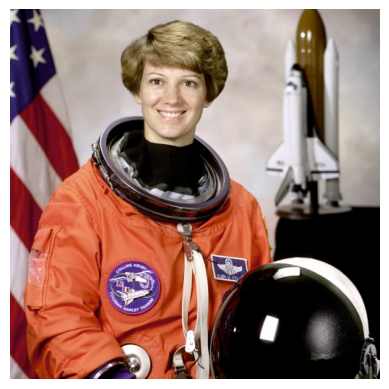

In [5]:
image = data.astronaut()

plt.imshow(image)
plt.axis("off")
plt.show()

In [6]:
cv2.imwrite("sample.jpg",
            cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

True

In [7]:
model = YOLO("yolov8n.pt")


image 1/1 /content/sample.jpg: 640x640 1 person, 487.3ms
Speed: 22.5ms preprocess, 487.3ms inference, 45.4ms postprocess per image at shape (1, 3, 640, 640)


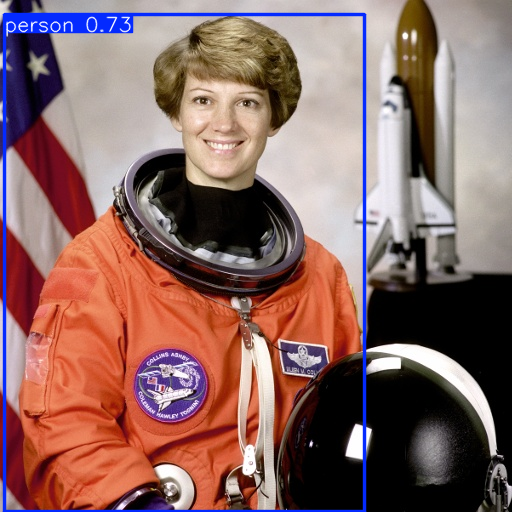

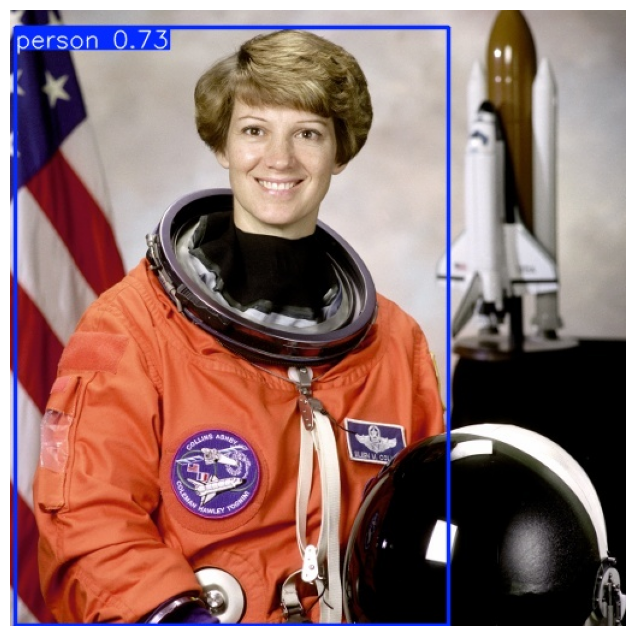

In [8]:
results = model("sample.jpg")

results[0].show()

results[0].save("output.jpg")


output = cv2.imread("output.jpg")

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [9]:
for box in results[0].boxes:

    cls = int(box.cls)

    confidence = float(box.conf)

    print(model.names[cls],
          round(confidence,2))

person 0.73


In [11]:
#ocr

reader = easyocr.Reader(['en'])
text=reader.readtext("sample.jpg")
print(text)

for item in text:

    print(item[1])

[]
